# Entrega PCA Grupo16:

Integrantes:
- Eduardo Montecinos
- Jose Silva
- Matías Toledo

In [44]:
# install.packages(c("corrplot","ggplot2"))
library(corrplot)
library(ggplot2)
options(scipen = 999)

# Ejercicio 1: educacion_v5.csv

In [45]:
datos1_raw <- read.csv("educacion_v5.csv", dec = ".", sep = ";", header = TRUE)
datos1 <- datos1_raw[, 1:5]
datos1 <- datos1[complete.cases(datos1), ]
summary(datos1)
dim(datos1)

     horas          asistencia         tareas          retrasos     
 Min.   : 0.740   Min.   : 34.82   Min.   : 51.26   Min.   :-1.820  
 1st Qu.: 3.240   1st Qu.: 67.36   1st Qu.: 76.51   1st Qu.: 0.860  
 Median : 4.090   Median : 74.87   Median : 84.24   Median : 2.020  
 Mean   : 4.357   Mean   : 78.54   Mean   : 92.61   Mean   : 2.125  
 3rd Qu.: 4.850   3rd Qu.: 84.43   3rd Qu.: 92.87   3rd Qu.: 3.150  
 Max.   :16.120   Max.   :187.57   Max.   :322.91   Max.   : 8.990  
 planificacion   
 Min.   : 0.640  
 1st Qu.: 2.550  
 Median : 3.080  
 Mean   : 3.208  
 3rd Qu.: 3.550  
 Max.   :10.090  

[1] 477   5

In [29]:
# Normalizacion datos
scaled_df1 <- apply(datos1, 2, scale)
summary(scaled_df1)
apply(scaled_df1, 2, var)
apply(scaled_df1, 2, mean)

     horas           asistencia          tareas             retrasos       
 Min.   :-1.8074   Min.   :-2.1640   Min.   :-1.014022   Min.   :-2.30991  
 1st Qu.:-0.5582   1st Qu.:-0.5533   1st Qu.:-0.394856   1st Qu.:-0.74088  
 Median :-0.1335   Median :-0.1816   Median :-0.205305   Median :-0.06175  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.000000   Mean   : 0.00000  
 3rd Qu.: 0.2462   3rd Qu.: 0.2916   3rd Qu.: 0.006315   3rd Qu.: 0.59982  
 Max.   : 5.8776   Max.   : 5.3967   Max.   : 5.647231   Max.   : 4.01889  
 planificacion    
 Min.   :-2.0505  
 1st Qu.:-0.5253  
 Median :-0.1021  
 Mean   : 0.0000  
 3rd Qu.: 0.2732  
 Max.   : 5.4956  

horas    asistencia        tareas      retrasos planificacion 
            1             1             1             1             1

horas                 asistencia 
 0.00000000000000007496805 -0.00000000000000019688555 
                    tareas                   retrasos 
 0.00000000000000016607307  0.00000000000000011463938 
             planificacion 
 0.00000000000000001284349

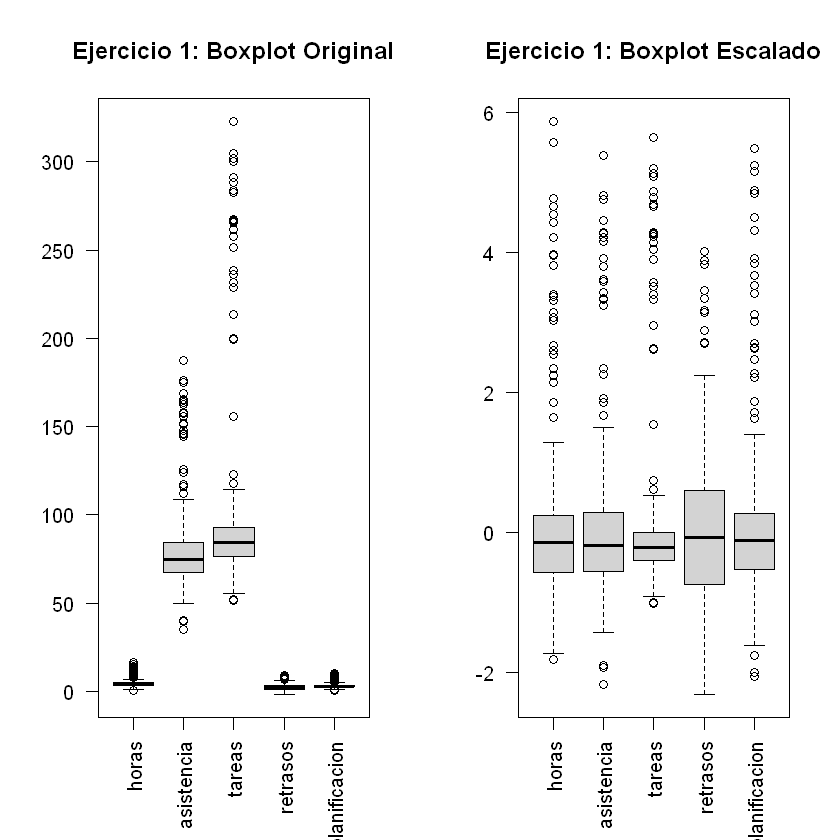

In [30]:
# Grafico 1: boxplots antes y despues de normalizar
par(mfrow = c(1, 2))
boxplot(datos1, main = "Ejercicio 1: Boxplot Original", las = 2)
boxplot(scaled_df1, main = "Ejercicio 1: Boxplot Escalado", las = 2)
par(mfrow = c(1, 1))

                  horas asistencia    tareas  retrasos planificacion
horas         1.0000000  0.6281784 0.7449154 0.2488810     0.5996606
asistencia    0.6281784  1.0000000 0.7449443 0.2061532     0.5859456
tareas        0.7449154  0.7449443 1.0000000 0.3361414     0.7280632
retrasos      0.2488810  0.2061532 0.3361414 1.0000000     0.2666927
planificacion 0.5996606  0.5859456 0.7280632 0.2666927     1.0000000


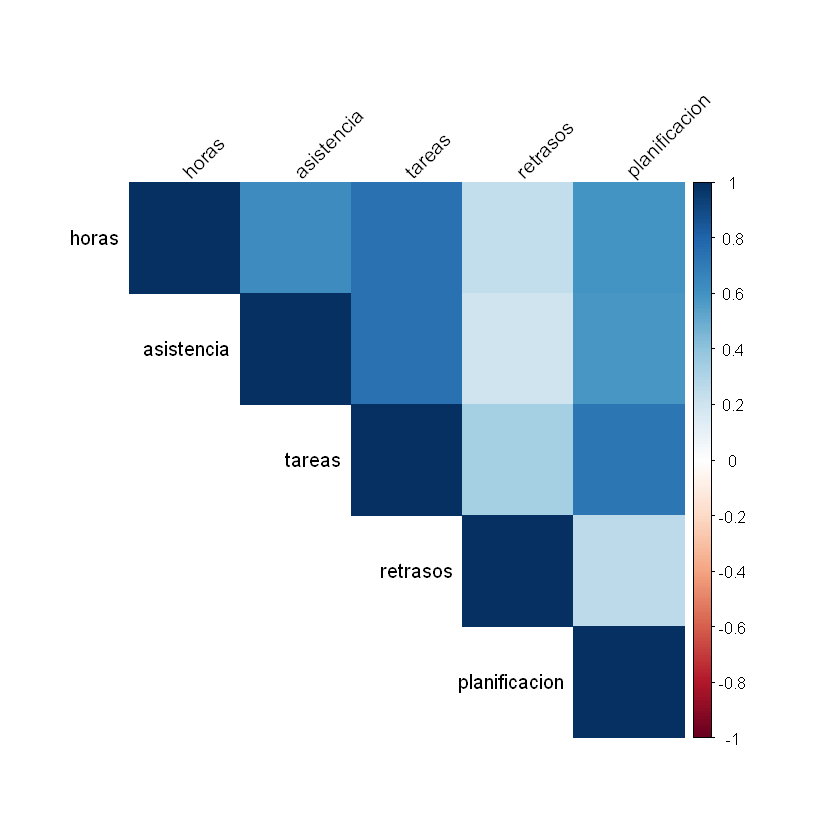

In [31]:
# Grafico 2: correlaciones en datos escalados
mcor1 <- cor(scaled_df1)
corrplot(mcor1, method = "color", type = "upper", tl.col = "black", tl.srt = 45)
print(mcor1)

In [32]:
# PCA
mdat.cov1 <- cov(scaled_df1)
mdat.eigen1 <- eigen(mdat.cov1)
w1 <- -mdat.eigen1$vectors[, 1:2]
row.names(w1) <- colnames(scaled_df1)
colnames(w1) <- c("PC1", "PC2")
w1

,PC1,PC2
horas,0.4768340,-0.13487116
asistencia,0.4708428,-0.21401512
tareas,0.5237787,-0.05623068
retrasos,0.2400231,0.96267866
planificacion,0.4679543,-0.07807183


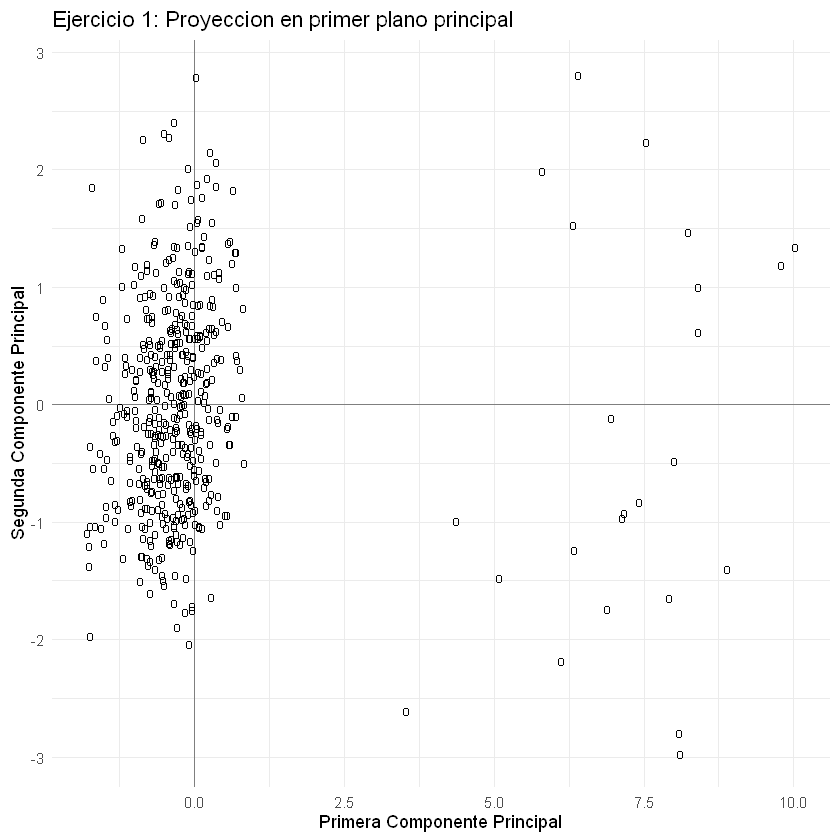

In [33]:
# Grafico 3: proyeccion en primer plano principal
PC1_1 <- as.matrix(scaled_df1) %*% w1[, 1]
PC2_1 <- as.matrix(scaled_df1) %*% w1[, 2]
PC_1 <- data.frame(PC1 = PC1_1, PC2 = PC2_1)
ggplot(PC_1, aes(PC1, PC2)) +
  geom_hline(yintercept = 0, color = "gray50") +
  geom_vline(xintercept = 0, color = "gray50") +
  geom_text(aes(label = 'o'), size = 3) +
  xlab("Primera Componente Principal") +
  ylab("Segunda Componente Principal") +
  ggtitle("Ejercicio 1: Proyeccion en primer plano principal")

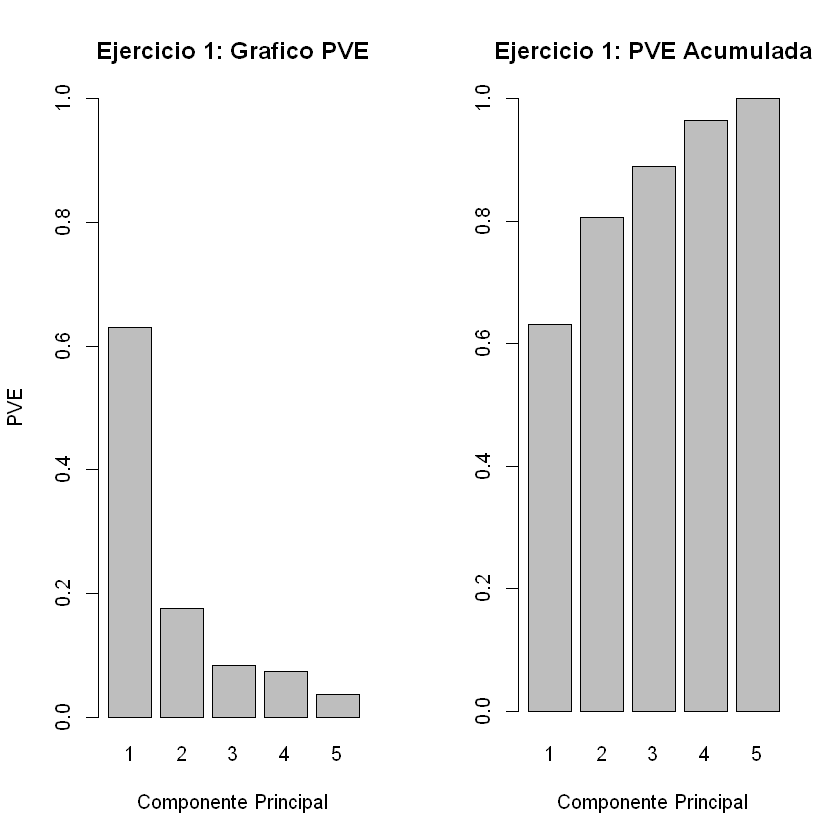

In [34]:
# Grafico 4: PVE y PVE acumulada
PVE1 <- mdat.eigen1$values / sum(mdat.eigen1$values)
par(mfrow = c(1, 2))
barplot(PVE1, xlab = "Componente Principal", ylab = "PVE", main = "Ejercicio 1: Grafico PVE", ylim = c(0, 1), names.arg = c(1:length(PVE1)))
barplot(cumsum(PVE1), xlab = "Componente Principal", ylab = "", main = "Ejercicio 1: PVE Acumulada", names.arg = c(1:length(PVE1)))
par(mfrow = c(1, 1))

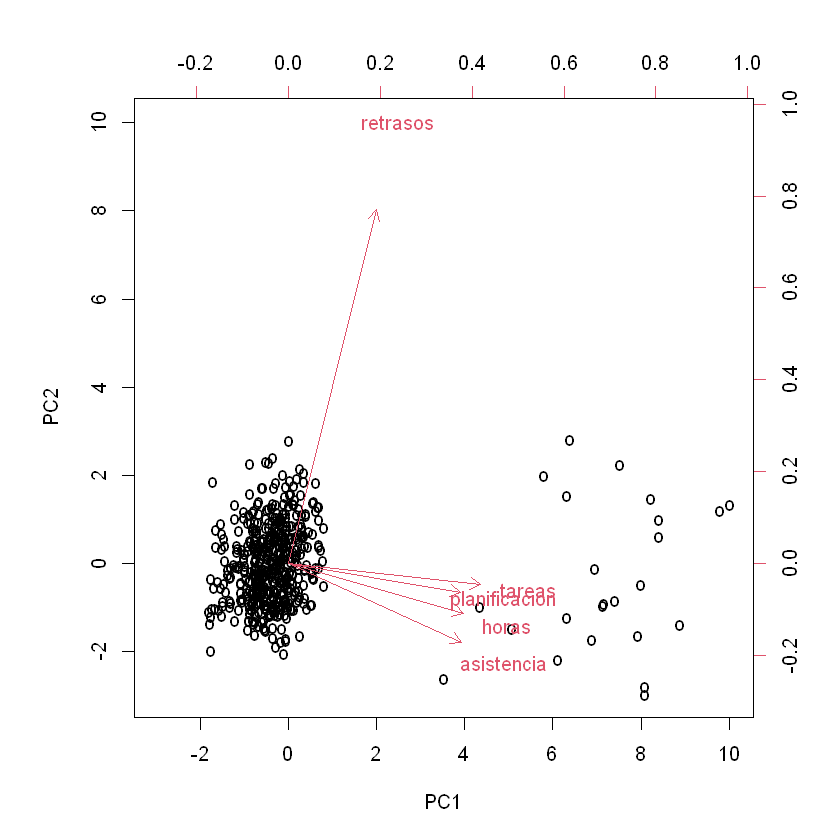

In [35]:
# Biplot
pca_res1 <- prcomp(datos1, scale = TRUE)
pca_res1$rotation <- -pca_res1$rotation
pca_res1$x <- -pca_res1$x
biplot(pca_res1, scale = 0, xlabs = rep('o', nrow(datos1)))

## Pregunta 1
### Explique como se obtienen las coordenadas de  variables y observaciones en el gráfico biplot y como se interpreta la representación obtenida.

## Pregunta 2
### Compare los resultados obtenidos utilizando la función predefinida en R prcomp con aquellos de los cálculos previos. Explique a que corresponden cada una de las componente del objeto resultante de utilizar la función prcomp. 

# Ejercicio 2: Grupo16.csv

## Pregunta 1:
### Realice un análisis exploratorio de los datos de las características de sus datos, incluyendo resúmenes de cada variable, boxplots, correlaciones y análisis de componentes principales (PCA).

In [36]:
datos2_raw <- read.csv("Grupo16.csv", header = TRUE, sep = ";")
datos2 <- datos2_raw[, 1:(ncol(datos2_raw) - 2)]
datos2 <- datos2[, sapply(datos2, is.numeric), drop = FALSE]
datos2 <- datos2[complete.cases(datos2), , drop = FALSE]
summary(datos2)
dim(datos2)

   frecuencia         gasto            visitas        devoluciones   
 Min.   :-2.360   Min.   :-189.90   Min.   :-17.90   Min.   :-4.150  
 1st Qu.: 3.450   1st Qu.:  41.20   1st Qu.: 26.34   1st Qu.: 0.975  
 Median : 5.060   Median :  60.62   Median : 42.24   Median : 1.950  
 Mean   : 5.066   Mean   :  62.97   Mean   : 42.74   Mean   : 2.206  
 3rd Qu.: 6.690   3rd Qu.:  83.72   3rd Qu.: 56.57   3rd Qu.: 3.170  
 Max.   :16.490   Max.   : 277.54   Max.   :158.36   Max.   :13.570  
 satisfaccion_cliente
 Min.   :0.010       
 1st Qu.:0.925       
 Median :1.240       
 Mean   :1.467       
 3rd Qu.:1.795       
 Max.   :5.740       

[1] 475   5

In [37]:
# Normalizacion
scaled_df2 <- apply(datos2, 2, scale)
summary(scaled_df2)
apply(scaled_df2, 2, var)
apply(scaled_df2, 2, mean)

   frecuencia            gasto             visitas          devoluciones    
 Min.   :-2.962738   Min.   :-6.04027   Min.   :-2.37513   Min.   :-3.3293  
 1st Qu.:-0.644700   1st Qu.:-0.51980   1st Qu.:-0.64245   1st Qu.:-0.6446  
 Median :-0.002352   Median :-0.05603   Median :-0.01972   Median :-0.1338  
 Mean   : 0.000000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.647975   3rd Qu.: 0.49564   3rd Qu.: 0.54152   3rd Qu.: 0.5052  
 Max.   : 4.557919   Max.   : 5.12559   Max.   : 4.52816   Max.   : 5.9532  
 satisfaccion_cliente
 Min.   :-1.7074     
 1st Qu.:-0.6348     
 Median :-0.2656     
 Mean   : 0.0000     
 3rd Qu.: 0.3850     
 Max.   : 5.0092     

frecuencia                gasto              visitas 
                   1                    1                    1 
        devoluciones satisfaccion_cliente 
                   1                    1

frecuencia                      gasto 
-0.00000000000000016511600  0.00000000000000003968572 
                   visitas               devoluciones 
-0.00000000000000013563346 -0.00000000000000005485298 
      satisfaccion_cliente 
 0.00000000000000010149228

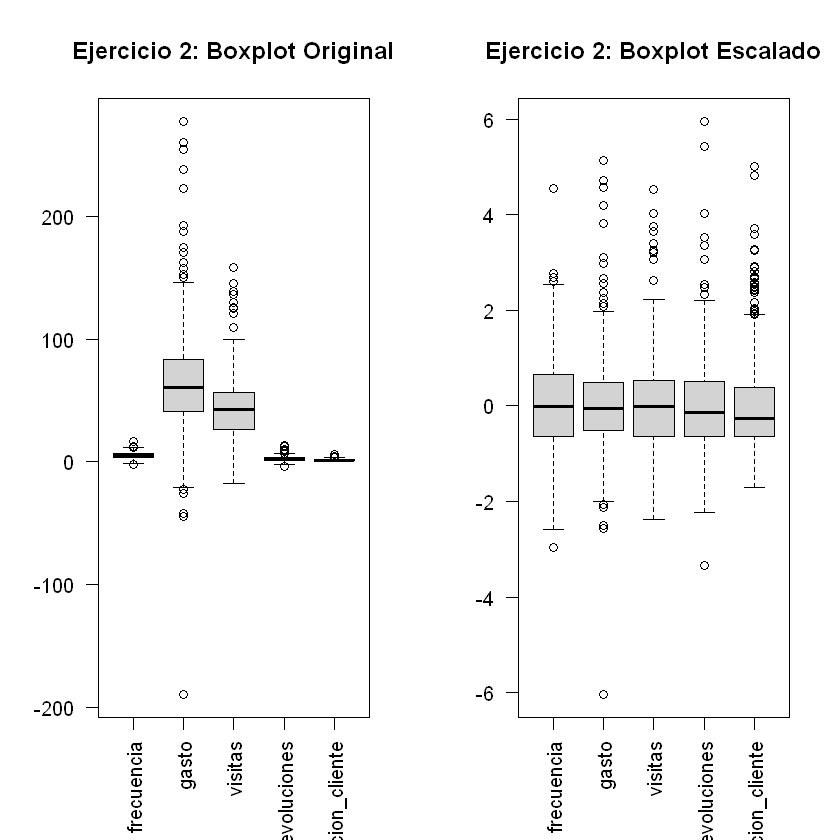

In [38]:
# Grafico 1: boxplots antes y despues de normalizar
par(mfrow = c(1, 2))
boxplot(datos2, main = "Ejercicio 2: Boxplot Original", las = 2)
boxplot(scaled_df2, main = "Ejercicio 2: Boxplot Escalado", las = 2)
par(mfrow = c(1, 1))

                     frecuencia      gasto    visitas devoluciones
frecuencia           1.00000000 0.06746577 0.09864652   0.05622846
gasto                0.06746577 1.00000000 0.24256016   0.10782317
visitas              0.09864652 0.24256016 1.00000000   0.11371450
devoluciones         0.05622846 0.10782317 0.11371450   1.00000000
satisfaccion_cliente 0.05799582 0.40629577 0.23517069  -0.12597736
                     satisfaccion_cliente
frecuencia                     0.05799582
gasto                          0.40629577
visitas                        0.23517069
devoluciones                  -0.12597736
satisfaccion_cliente           1.00000000


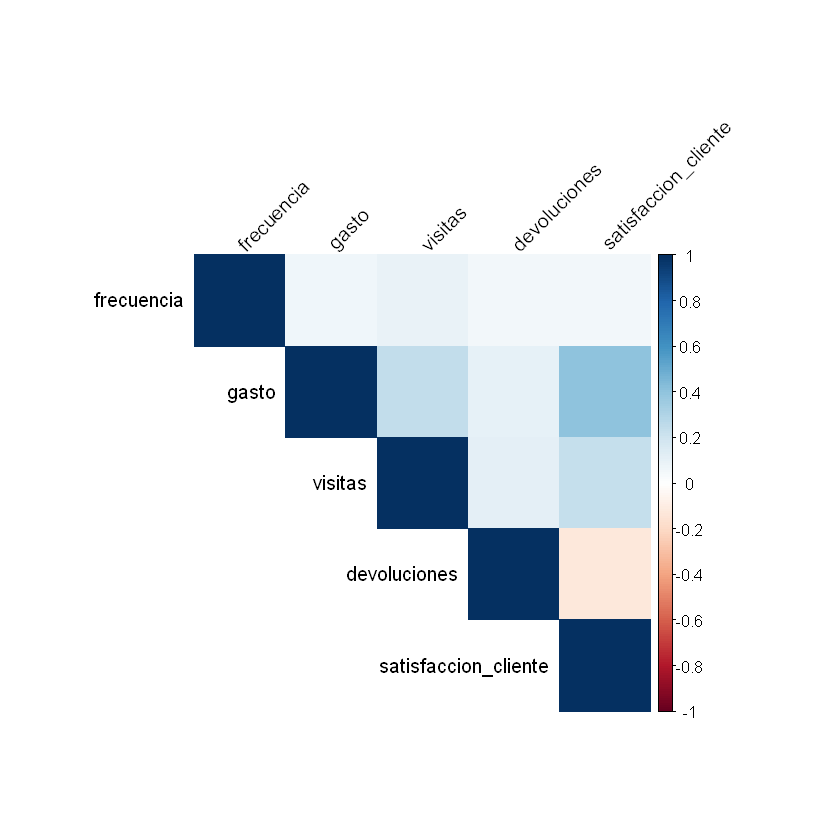

In [39]:
# Grafico 2: correlaciones en datos escalados
mcor2 <- cor(scaled_df2)
corrplot(mcor2, method = "color", type = "upper", tl.col = "black", tl.srt = 45)
print(mcor2)

In [40]:
# PCA
mdat.cov2 <- cov(scaled_df2)
mdat.eigen2 <- eigen(mdat.cov2)
w2 <- -mdat.eigen2$vectors[, 1:2]
row.names(w2) <- colnames(scaled_df2)
colnames(w2) <- c("PC1", "PC2")
w2

,PC1,PC2
frecuencia,-0.20527204,0.35739185
gasto,-0.60476456,-0.03316262
visitas,-0.49930393,0.20846570
devoluciones,-0.09672911,0.81281322
satisfaccion_cliente,-0.57746193,-0.40871511


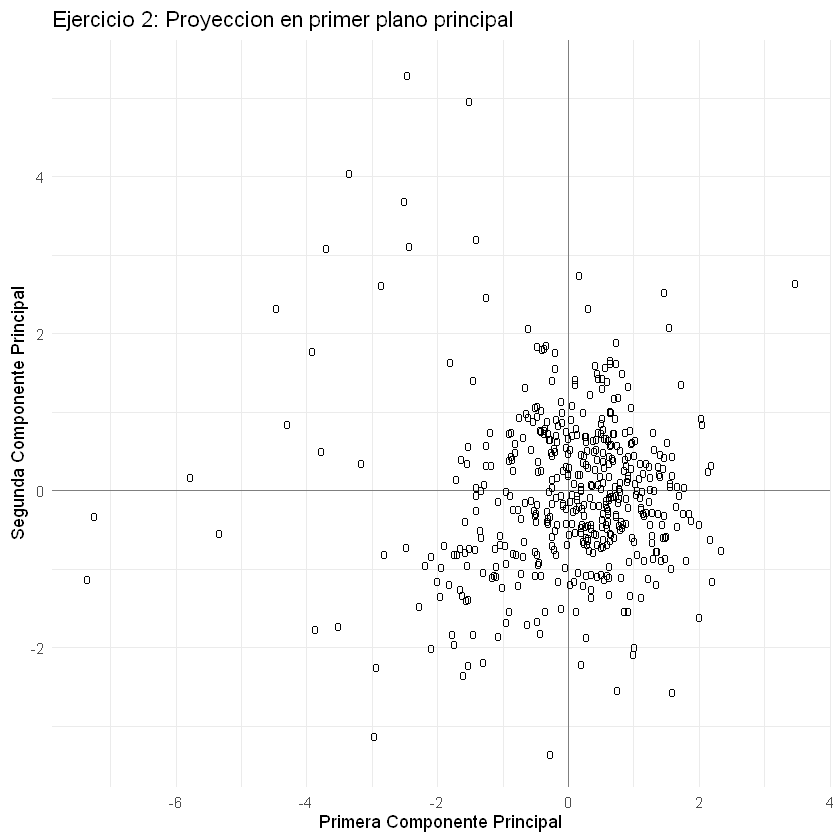

In [41]:
# Grafico 3: proyeccion en primer plano principal
PC1_2 <- as.matrix(scaled_df2) %*% w2[, 1]
PC2_2 <- as.matrix(scaled_df2) %*% w2[, 2]
PC_2 <- data.frame(PC1 = PC1_2, PC2 = PC2_2)
ggplot(PC_2, aes(PC1, PC2)) +
  geom_hline(yintercept = 0, color = "gray50") +
  geom_vline(xintercept = 0, color = "gray50") +
  geom_text(aes(label = 'o'), size = 3) +
  xlab("Primera Componente Principal") +
  ylab("Segunda Componente Principal") +
  ggtitle("Ejercicio 2: Proyeccion en primer plano principal")

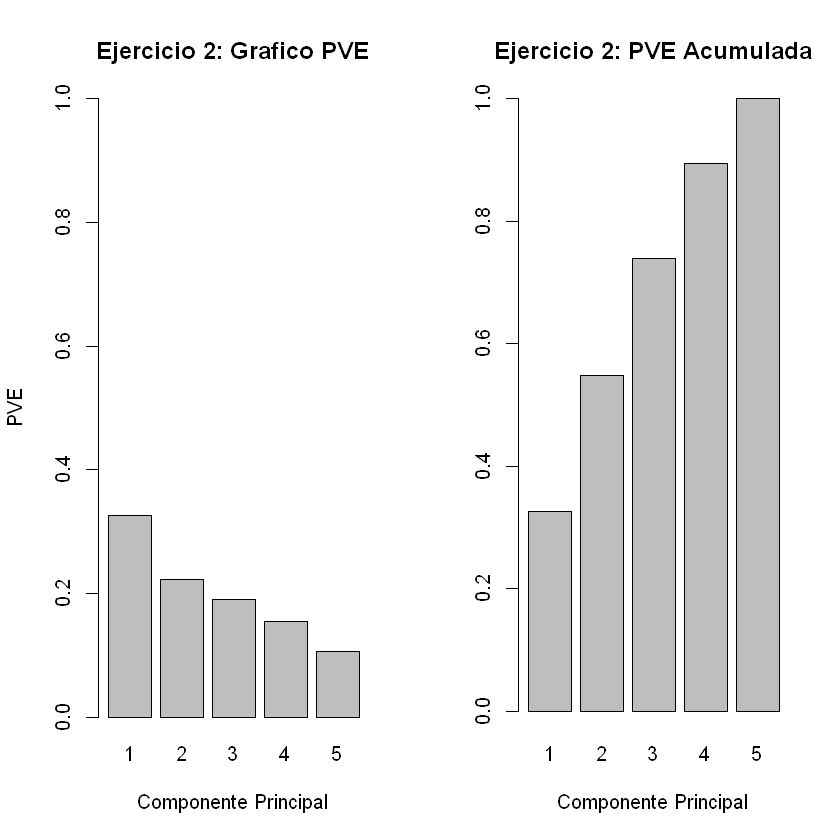

In [42]:
# Grafico 4: PVE y PVE acumulada
PVE2 <- mdat.eigen2$values / sum(mdat.eigen2$values)
par(mfrow = c(1, 2))
barplot(PVE2, xlab = "Componente Principal", ylab = "PVE", main = "Ejercicio 2: Grafico PVE", ylim = c(0, 1), names.arg = c(1:length(PVE2)))
barplot(cumsum(PVE2), xlab = "Componente Principal", ylab = "", main = "Ejercicio 2: PVE Acumulada", names.arg = c(1:length(PVE2)))
par(mfrow = c(1, 1))

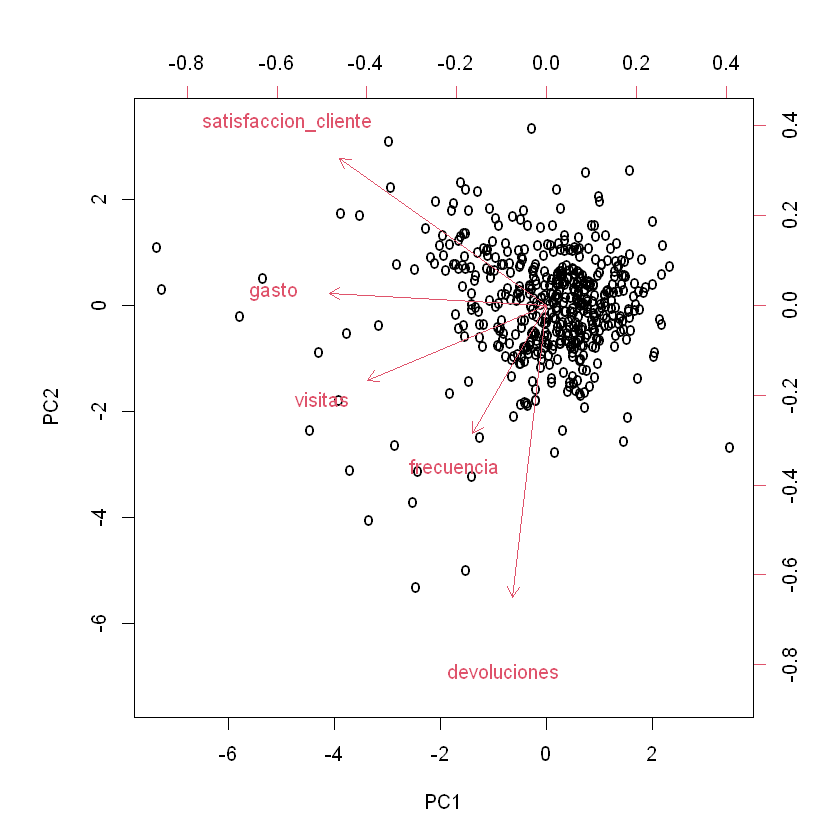

In [43]:
# Biplot con prcomp (como en el original)
pca_res2 <- prcomp(datos2, scale = TRUE)
pca_res2$rotation <- -pca_res2$rotation
pca_res2$x <- -pca_res2$x
biplot(pca_res2, scale = 0, xlabs = rep('o', nrow(datos2)))

## Pregunta 2:
### Interprete sus resultados en (1). Indique cual es el interés de utilizar PCA en este conjunto de datos y si se sugiere algún tipo de limpieza de datos a partir del análisis realizado.

